In [1]:
%run ~/analysisLibraries

In [2]:
%matplotlib inline

In [3]:
%load_ext rpy2.ipython

## Read data containing all necessary scores and relevant genes calculated in the previous notebook

In [4]:
adata = sc.read('./write/SDA_object_100comps.h5ad')

component can be changed using the software papermill to execute notebooks in the workflow

In [5]:
comp=0

In [6]:
# Parameters
comp = 36


## Open SDA matrices

In [7]:
A = pd.read_csv('ALLDATA_scaled_onematrix_data_100comps/it2000/A', sep=' ', header=None)
#B is only for multi-tissues tensor
#B = pd.read_csv('SDA/CELLS_sctransform_onematrix_data/it2000/B1', sep=' ', header=None)
X = pd.read_csv('ALLDATA_scaled_onematrix_data_100comps/it2000/X1', sep=' ', header=None)

$A$ contains the score of each cell in the components. This score can be used as a "soft clustering" once it is normalized. We will try to do that in the notebook that follows this one. 

In [8]:
A.shape

(10548, 100)

In [9]:
A.head()

,0,1,2,3,4,5,6,7,8,9,...,90,91,92,93,94,95,96,97,98,99
0,0.237044,-0.444741,-0.521709,-0.421176,-0.191632,-0.039443,-0.011519,0.313026,-0.017442,-0.014353,...,-0.713952,0.084345,0.325848,0.577062,-0.704971,-0.307896,0.102466,-0.919935,-0.196817,-1.101270
1,0.411126,-0.113899,-0.404359,-0.412903,0.112982,-0.168036,-0.364643,0.746365,-0.003497,-0.242012,...,0.923655,-0.432896,0.018581,-0.329805,-0.004898,-0.298961,0.290554,0.328762,-0.211422,0.605521
2,-0.554124,-2.115210,0.572701,-0.509780,0.577237,-0.234850,0.450509,0.208679,0.177719,-0.164977,...,-0.382789,0.511820,0.686443,0.116738,-0.315359,-0.109686,1.740900,-0.937221,0.846761,0.562644
3,-0.258430,1.402740,1.303190,-0.759115,1.298820,-0.058847,-0.725280,-0.359907,0.306425,1.195000,...,-0.727815,0.416148,2.020470,-0.108066,-0.465147,-1.716540,0.712520,-0.855888,0.907461,0.266163
4,-0.338097,1.336100,-1.538940,0.907896,0.817900,1.415150,-0.130066,-0.545487,-0.755909,-0.912024,...,-1.259190,-0.325736,0.157799,1.454890,-0.115039,-0.391225,1.149520,0.961979,-0.198099,0.624347


In [10]:
#B

$X$ contains the loading of each gene in each component according to the spike-and-slab prior. The sign of the loading has to be considered together with the sign of the cell score to see if the resulting sign is positive (significant expression of gene) or negative (significant underexpression of gene)

In [11]:
X.columns = adata[:,(np.log(adata.var['variance-Cells'])>0)|(np.log(adata.var['variance-Nuclei']>-1))].var_names

In [12]:
X.shape

(100, 6276)

In [13]:
X.head()

,AURKAIP1,MRPL20,SSU72,LOC469457,GNB1,MORN1,RER1,MMEL1,ACTRT2,CCDC27,...,amplicon-chrX-FAM9A/B/C-6,amplicon-chrX-GAGE10-0,amplicon-chrX-LOC107966365-0,amplicon-chrX-LOC112206844-0,amplicon-chrX-LOC112206844-2,amplicon-chrX-LOC112206844-4,amplicon-chrX-LOC465705-2,amplicon-chrX-PAGE5-3,amplicon-chrX-SPANXN5-2,amplicon-chrX-SSX1/3/2B-15
0,-0.251518,-0.050381,-0.000772,-0.082587,-0.000094,-0.001789,-0.132522,0.000048,-0.053861,-0.035661,...,0.000333,0.000363,-0.000149,-0.036358,-0.000366,0.002521,-0.061503,0.000056,0.000141,0.006134
1,0.000395,0.000193,-0.000607,0.001750,0.000787,-0.001956,-0.000217,-0.000121,0.000535,-0.000017,...,0.066423,-0.000271,0.000069,0.029602,0.001012,0.000030,-0.000178,0.000639,-0.026457,0.000855
2,-0.000250,-0.000108,-0.000195,0.030246,0.000202,-0.001048,-0.000112,0.000151,-0.001854,-0.000145,...,-0.000141,0.001418,-0.000997,-0.000141,-0.039148,-0.000122,0.000968,-0.000012,-0.001109,0.000334
3,0.000423,-0.000399,-0.000322,0.002582,0.000288,0.000177,-0.000765,0.046786,0.000218,0.000263,...,-0.000404,0.000993,0.000137,0.000224,0.043691,-0.000044,0.000219,0.000187,0.000062,-0.000340
4,-0.000056,-0.000013,0.000059,-0.000223,0.033124,-0.000006,0.000276,-0.107145,0.000001,-0.051293,...,-0.034791,0.000032,0.061013,-0.000074,-0.000050,0.000003,0.000006,0.000007,-0.000034,-0.037562


## Some plots and measures about the specific components

#### UMAP of cell scores and batches

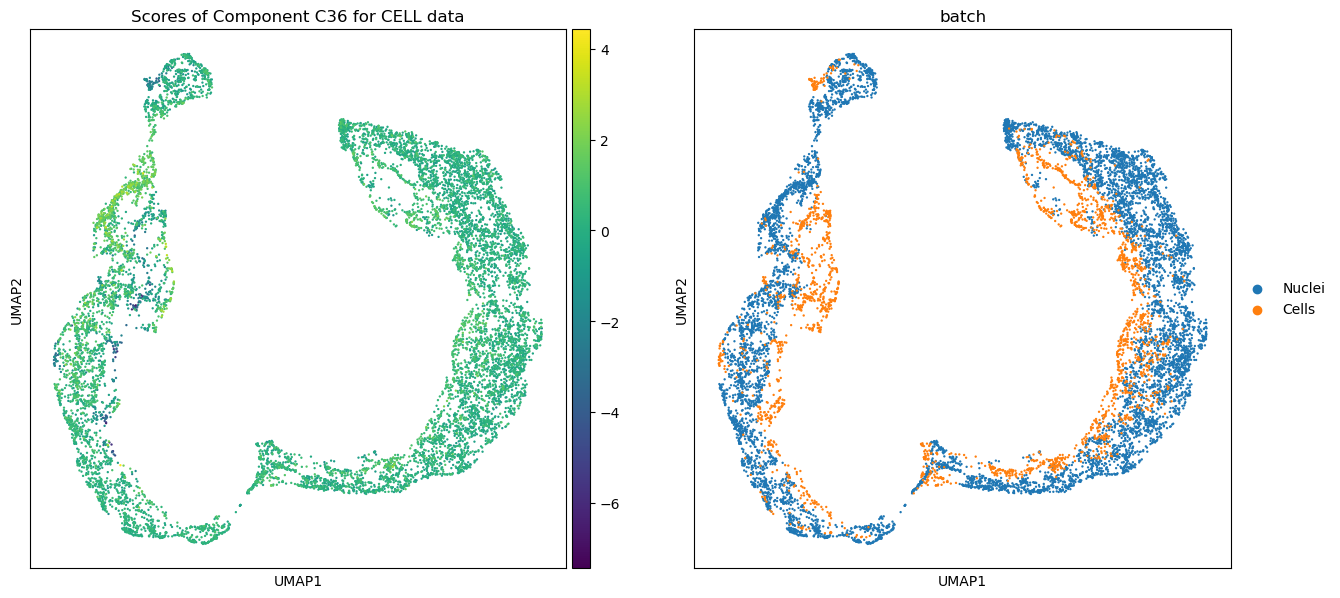

In [14]:
plt.rcParams['figure.figsize']=(7,7)
sc.pl.umap(adata, color=[f'SDA_cellscore_C{comp}','batch'],
          title=f'Scores of Component C{comp} for CELL data')

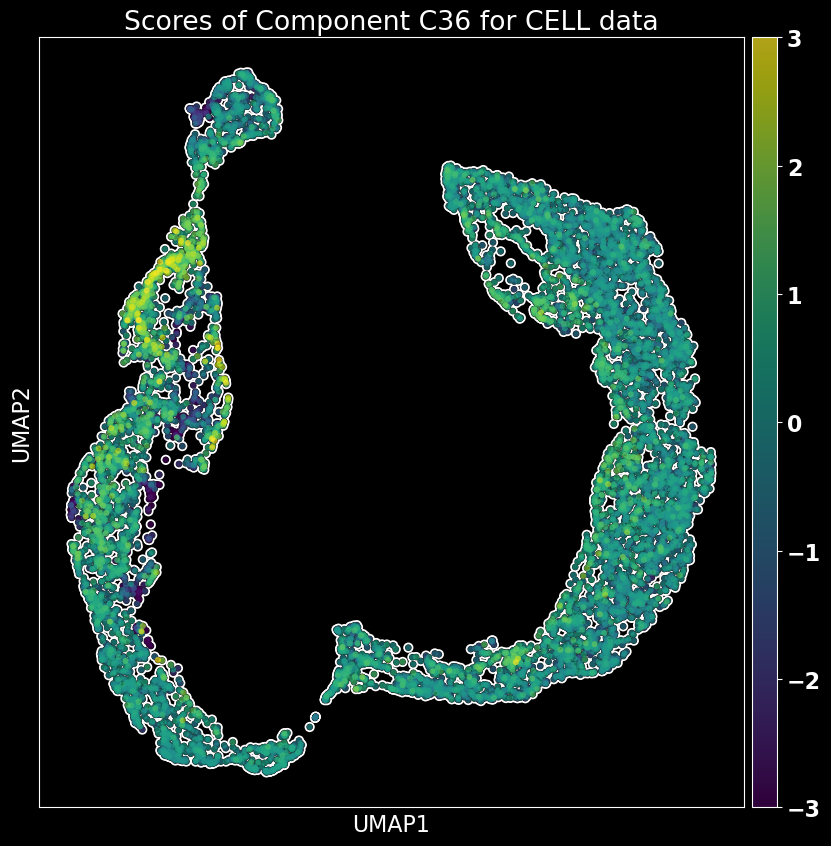

In [15]:
plt.rcParams['figure.figsize']=(10,10)
plt.style.use('dark_background')
plt.rc('font', size=16, weight='bold')
sc.pl.umap(adata, color=[f'SDA_cellscore_C{comp}'], vmin=-3, vmax=3, 
          title=f'Scores of Component C{comp} for CELL data', size=75,
          add_outline=True, outline_color=['white','black'],
          save=f'scores_C{comp}_dark.png', )

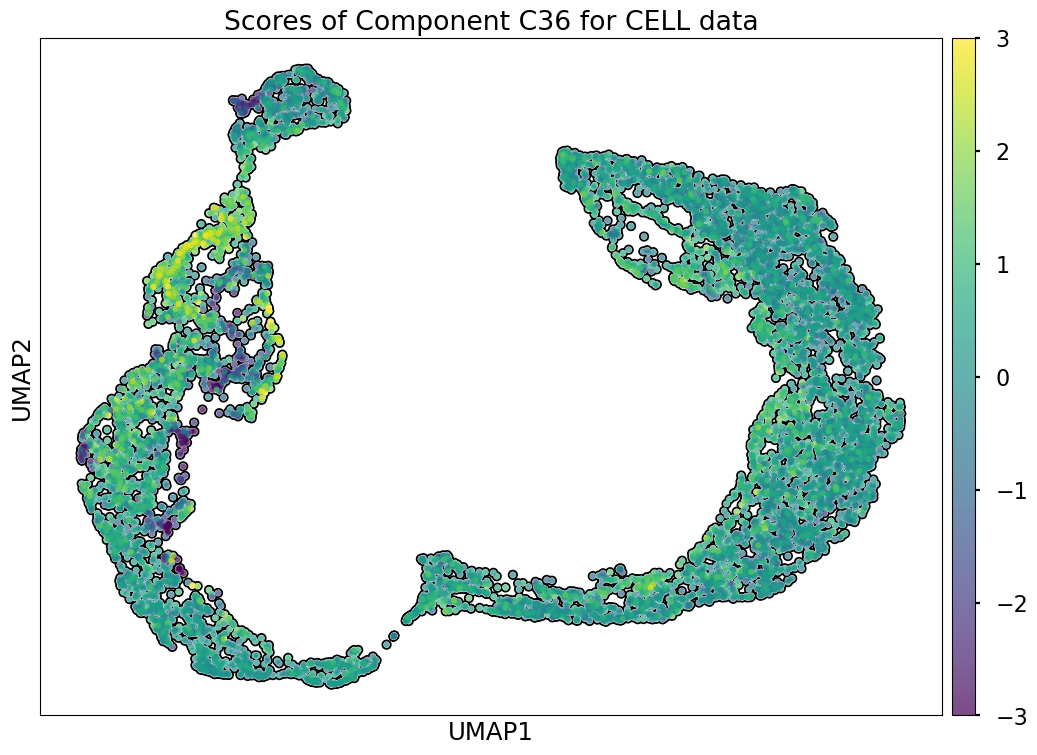

In [16]:
plt.rcParams['figure.figsize']=(10,10)
plt.style.use('default')
plt.style.use('seaborn-v0_8-poster')
sc.pl.umap(adata, color=[f'SDA_cellscore_C{comp}'], vmin=-3, vmax=3, 
          title=f'Scores of Component C{comp} for CELL data', size=75,
          add_outline=True,
          save=f'scores_C{comp}_white.png', )

In [17]:
try:
    IRRELEVANT=adata.obs[f'sda_cell_relevant_C{comp}'].value_counts()['IRRELEVANT']
except Exception as e:
    IRRELEVANT=0
try:
    POSITIVE=adata.obs[f'sda_cell_relevant_C{comp}'].value_counts()['POSITIVE']
except Exception as e:
    POSITIVE=0
try:
    NEGATIVE=adata.obs[f'sda_cell_relevant_C{comp}'].value_counts()['NEGATIVE']
except Exception as e:
     NEGATIVE=0

In [18]:
onlyrelevant = np.array( adata.obs[f'sda_cell_relevant_C{comp}'].copy() )
onlyrelevant[onlyrelevant=='IRRELEVANT']=None
adata.obs[f'sda_cell_relevantonly_C{comp}'] = onlyrelevant

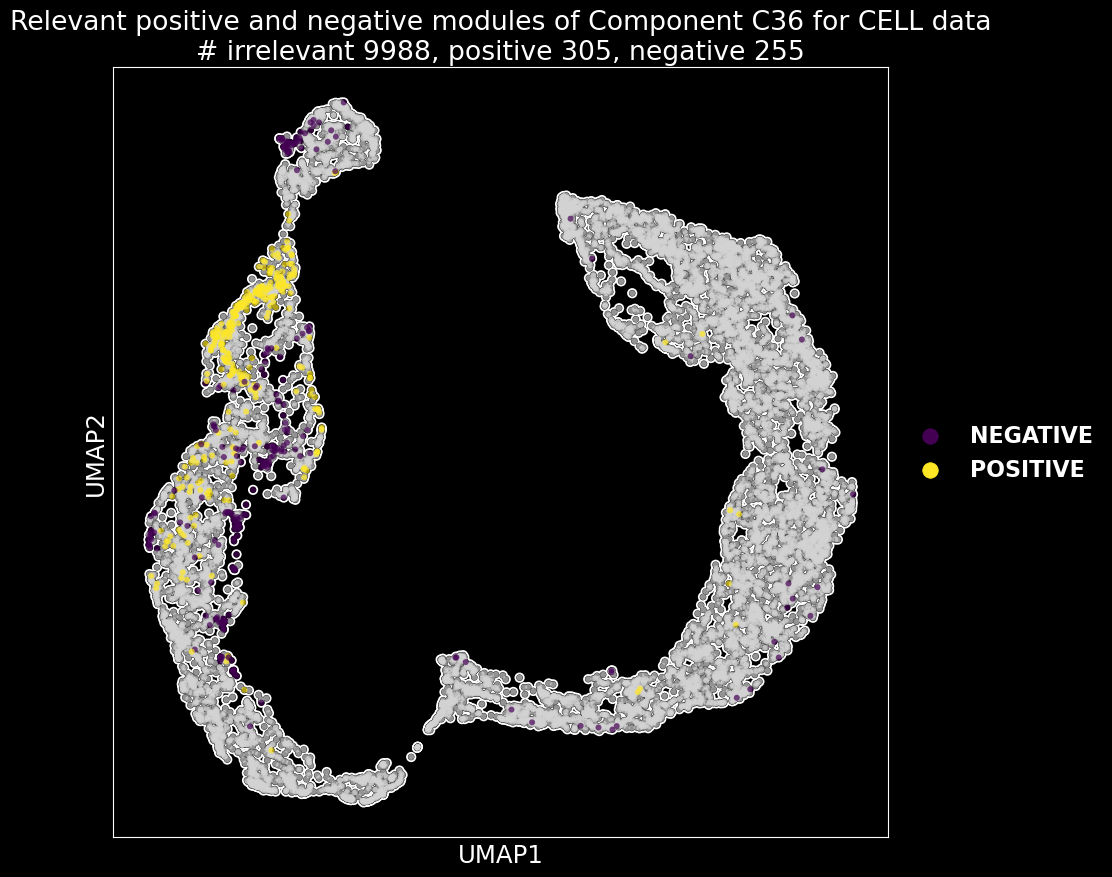

In [19]:
plt.rcParams['figure.figsize']=(10,10)
plt.style.use('dark_background')
plt.rc('font', size=16, weight='bold')
sc.pl.umap(adata, color=[f'sda_cell_relevantonly_C{comp}'], vmin=-3, vmax=3, na_in_legend=False, na_color='lightgray',
          title=f'Relevant positive and negative modules of Component C{comp} for CELL data\n# irrelevant {IRRELEVANT}, positive {POSITIVE}, negative {NEGATIVE}', 
          size=75, add_outline=True, outline_color=['white','black'], palette='viridis',
          save=f'relevance_C{comp}_dark.png')

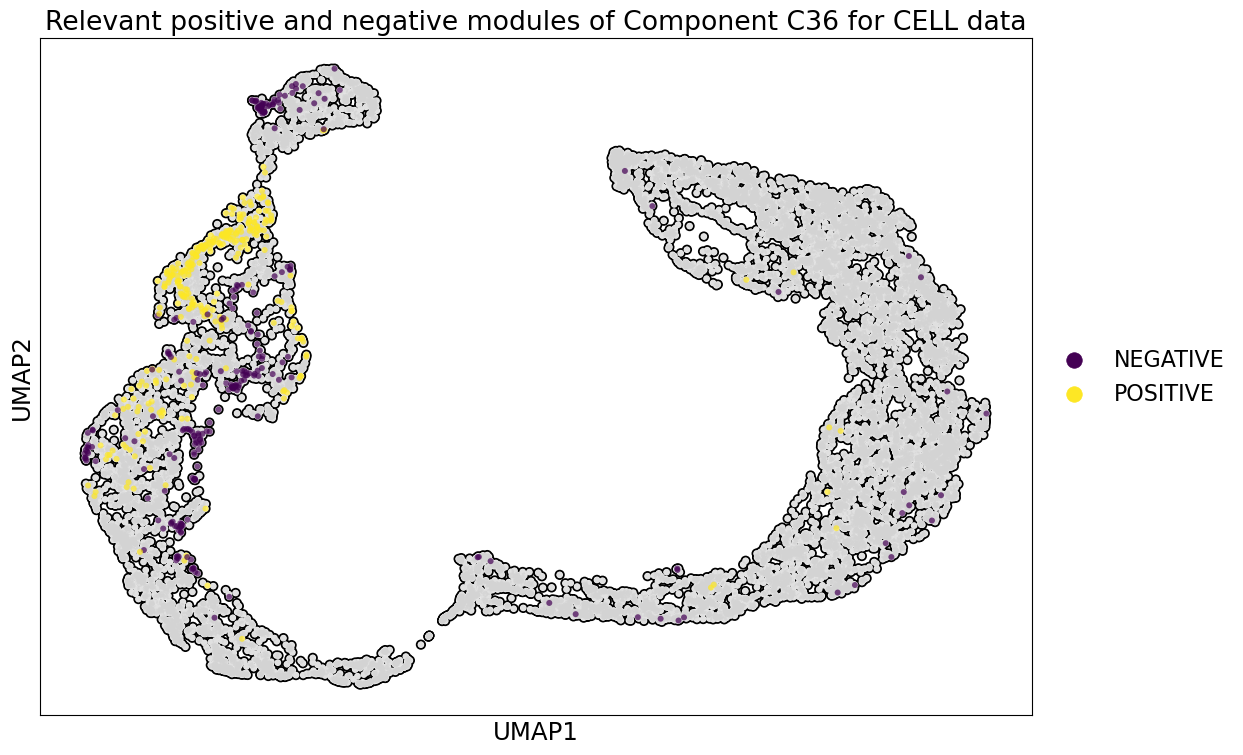

In [20]:
plt.rcParams['figure.figsize']=(10,10)
plt.style.use('default')
plt.style.use('seaborn-v0_8-poster')
sc.pl.umap(adata, color=[f'sda_cell_relevantonly_C{comp}'], vmin=-3, vmax=3, na_in_legend=False, na_color='lightgray',
          title=f'Relevant positive and negative modules of Component C{comp} for CELL data', palette='viridis',
          size=75, add_outline=True,
          save=f'relevance_C{comp}_white.png')

### mean and std of positive and negative cell scores for each batch

In [21]:
score_cells = adata[adata.obs['batch']=='Cells'].obs[f'SDA_cellscore_C{comp}']
score_nuclei = adata[adata.obs['batch']=='Nuclei'].obs[f'SDA_cellscore_C{comp}']

In [22]:
print( 'Positive scores nuclei - mean:', np.mean(score_nuclei[score_nuclei>1.5]), 'var:', np.std(score_nuclei[score_nuclei>1.5])  )
print( 'Positive scores cells  - mean:', np.mean(score_cells[score_cells>2]), 'var:', np.std(score_cells[score_cells>2])  )

Positive scores nuclei - mean: 1.9675937078651686 var: 0.4142322893807923
Positive scores cells  - mean: 2.520787105263158 var: 0.47663483705479615


In [23]:
print( 'Negative scores nuclei - mean:', np.mean(score_nuclei[score_nuclei<-1.5]), 'var:', np.std(score_nuclei[score_nuclei<-1.5])  )
print( 'Negative scores cells  - mean:', np.mean(score_cells[score_cells<-2]), 'var:', np.std(score_cells[score_cells<-2])  )

Negative scores nuclei - mean: -1.7454934999999998 var: 0.3353615244221525
Negative scores cells  - mean: -3.194250697674418 var: 1.1329746352516896


### T-test to detect batch differences in a module

We check if positive/negative scores are specific for either cells or genes, so we can highlight that in our information output

In [24]:
import scipy

Two-sided test of positive scores of cells vs nuclei

In [25]:
scipy.stats.ttest_ind( score_cells[score_cells>0], score_nuclei[score_nuclei>0])

Ttest_indResult(statistic=12.464666371207931, pvalue=3.5953276509217717e-35)

Two-sided test of negative scores of cells vs nuclei

In [26]:
scipy.stats.ttest_ind( score_cells[score_cells<0], score_nuclei[score_nuclei<0])

Ttest_indResult(statistic=-40.31168696429508, pvalue=1.20048270814327e-309)

Cells have more transcripts than nuclei and this is reflected in a bit higher/lower score in general, so we choose a strict threshold to avoid detecting batch differences where they are mostly due to technical causes

In [27]:
pos_stat, pos_p = scipy.stats.ttest_ind( score_cells[score_cells>0], score_nuclei[score_nuclei>0])
neg_stat, neg_p = scipy.stats.ttest_ind( score_cells[score_cells<0], score_nuclei[score_nuclei<0])

batch_effect_pos='No'
batch_effect_neg='No'

if np.abs(pos_stat) > 10:
    batch_effect_pos='Yes'
print(f'Positive module batch differences: {batch_effect_pos}')
    
if np.abs(neg_stat) > 10:
    batch_effect_neg='Yes'
print(f'Negative module batch differences: {batch_effect_neg}')

Positive module batch differences: Yes
Negative module batch differences: Yes


<Axes: xlabel='SDA_cellscore_C36', ylabel='Count'>

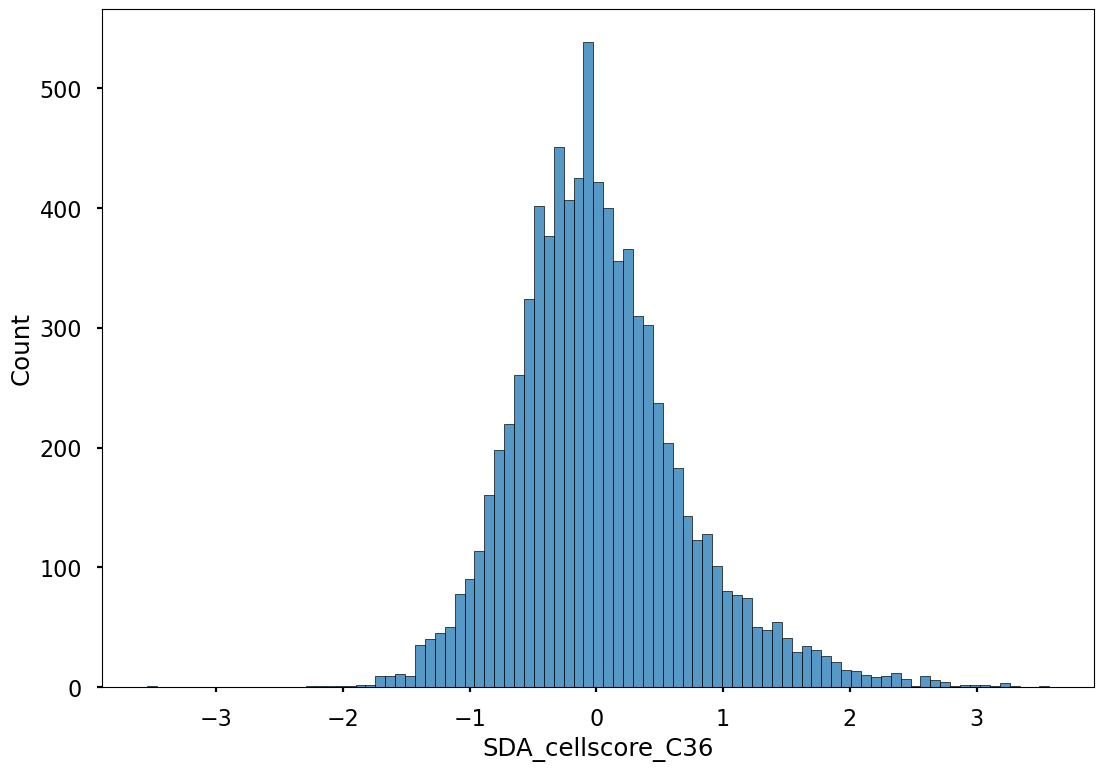

In [28]:
plt.rcParams['figure.figsize']=(6,6)
plt.style.use('default')
plt.style.use('seaborn-v0_8-poster')
sns.histplot(adata[adata.obs['batch']=='Nuclei'].obs[f'SDA_cellscore_C{comp}'])

<Axes: xlabel='SDA_cellscore_C36', ylabel='Count'>

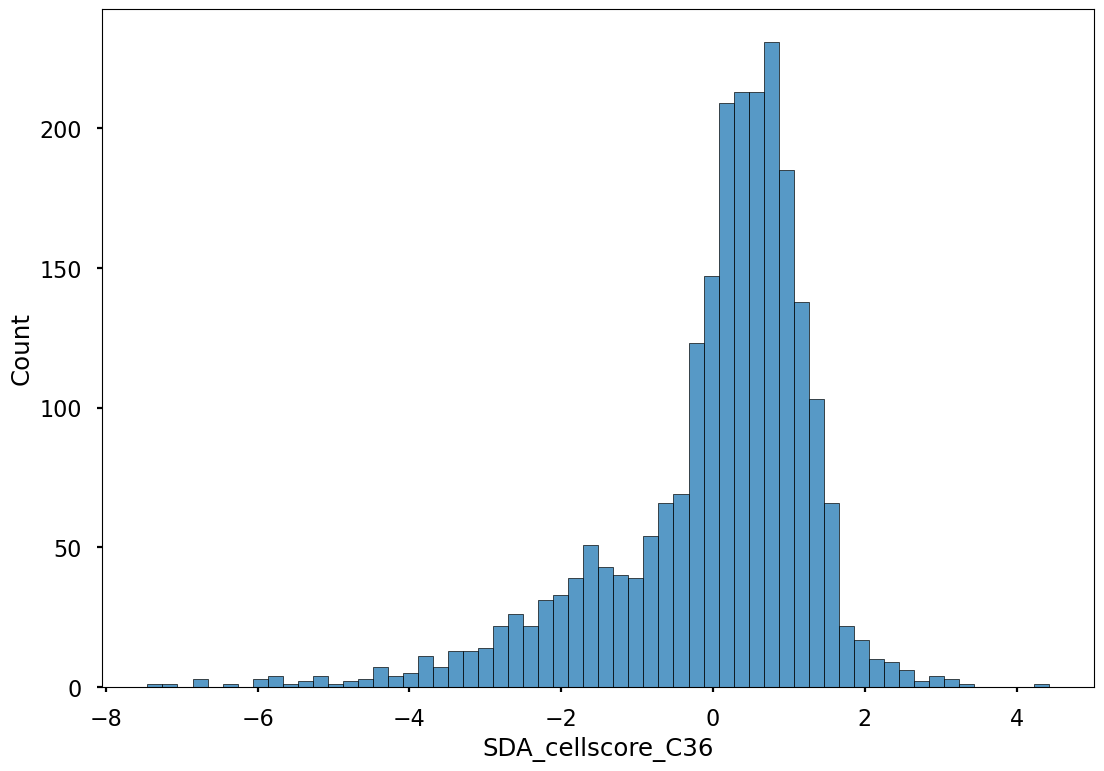

In [29]:
sns.histplot(adata[adata.obs['batch']=='Cells'].obs[f'SDA_cellscore_C{comp}'])

Genes significant for components (whole list printed to easy copy-pase for onlyne databases):

In [30]:
print(f'Genes significant for positive C{comp}:', adata[:,adata.var[f'sda_pos_C{comp}']].shape[1])

Genes significant for positive C36: 626


In [31]:
for i in adata[:,adata.var[f'sda_pos_C{comp}']].var_names:
    print(i)

PARK7
RERE
SDHB
DDOST
CLIC4
RPA2
EPB41
SRSF4
MECR
ZBTB8OS
PHC2
PSMB2
SCMH1
ATP6V0B
CCDC24
ZSWIM5
LOC742376
ATPAF1
RPL35A
EPS15
LOC107966681
TMEM59
TM2D1
ATG4C
ITGB3BP
SERBP1
ZZZ3
NEXN
RPF1
ZNHIT6
HS2ST1
GLMN
RPAP2
EVI5
RPL5
MFSD14A
CAPZA1
SYCP1
LOC112208384
GPR89A
RBM8A
RPS27
NUP210L
C1H1orf43
SDHC
LOC107969123
NUF2
DCAF6
NME7
ANKRD45
LOC112204100
RABGAP1L
ACBD6
SHCBP1L
SWT1
CRB1
UBE2T
TRIM17
LOC112206648
SLC35F3
C1H1orf100
DESI2
COX20
EFCAB2
RPS7
DCDC2C
YWHAQ
ODC1
NBAS
RAD51AP2
RHOB
PFN4
CCDC121
LCLAT1
SRSF7
MAP4K3
EML4
THADA
LOC104004979
WDPCP
UGP2
APLF
NFU1
AAK1
TPRKB
LOC107973527
CTNNA2
LOC112208191
UNC50
PTPN4
NIFK
ZRANB3
R3HDM1
MMADHC
ARL6IP6
PKP4
MARCH7
ITGB6
B3GALT1
BBS5
ATP5MC3
MTX2
AGPS
GULP1
PMS1
MFSD6
STAT4
HECW2
SPATS2L
ORC2
RPL37A
IGFBP2
TNP1
RHBDD1
CRBN
ITPR1
GRM7
OXNAD1
DAZL
TBC1D5
UBE2E2
UBE2E1
RPL15
CMC1
CLASP2
MLH1
RPSA
ANO10
PRSS50
RPL29
SPCS1
NEK4
DNAH12
ROBO1
CGGBP1
CMSS1
FILIP1L
STXBP5L
IQCB1
SEC22A
LOC104005737
ACAD11
CEP63
STAG1
CEP70
TRPC1
ARHGEF26
DHX36
IFT80

In [32]:
print(f'Genes significant for negative C{comp}:', adata[:,adata.var[f'sda_neg_C{comp}']].shape[1])

Genes significant for negative C36: 751


In [33]:
for i in adata[:,adata.var[f'sda_neg_C{comp}']].var_names:
    print(i)

LOC469457
MORN1
CHD5
SDF4
C1H1orf159
PRDM2
SPEN
UBR4
HP1BP3
LUZP1
CEP85
ARID1A
WASF2
PHACTR4
TXLNA
S100PBP
ZMYM4
MACF1
CDC20
TEX38
SSBP3
PDE4B
ZRANB2
LOC100615600
PRPF38B
HIPK1
C1H1orf56
PIP5K1A
TCHH
TDRD10
UBE2Q1
YY1AP1
UAP1
MROH9
PRRC2C
ABL2
DHX9
KCNT2
ASPM
ZC3H11A
NUCKS1
MAPKAPK2
DTL
MIA3
PARP1
HEATR1
AHCTF1
ALKAL2
MYT1L
KLF11
ROCK2
ITSN2
AGBL5
LRPPRC
NRXN1
SPTBN1
C2AH2orf74
XPO1
MPHOSPH10
ZNF638
KDM3A
LOC107973550
ACOXL
LOC112208188
LOC107971394
LOC107973562
SNRNP200
KANSL3
FER1L5
ANKRD36C
REV1
MAP4K4
LOC746383
C2AH2orf49
RANBP2
DDX18
CFAP221
UGGT1
KIF5C
RIF1
GALNT3
LNPK
SSFA2
NCKAP1
HSPD1
NOP58
RAPH1
ERBB4
SPAG16
USP37
RETREG2
PID1
NCL
PTMA
DGKD
HDAC4
HDLBP
STK25
SETD5
FANCD2OS
XPC
LOC100613308
NR2C2
ZNF385D
TOP2B
GOLGA4
EIF1B
ZDHHC3
SETD2
TMEM89
IP6K1
DCAF1
DNAH1
SFMBT1
FAM208A
APPL1
SLMAP
CRYBG3
HHLA2
GOLGB1
RPN1
CDV3
PPP2R3A
MSL2
PXYLP1
TIPARP
MECOM
ACTRT3
SKIL
KLHL24
EIF4G1
ATP13A3
ACAP2
SENP5
NCBP2
LOC107970887
FYTTD1
ADD1
FAM193A
RNF4
POLN
C4H4orf48
NSD2
TACC3
FAM53A
GAK
KIA

#### Cells scores by cluster

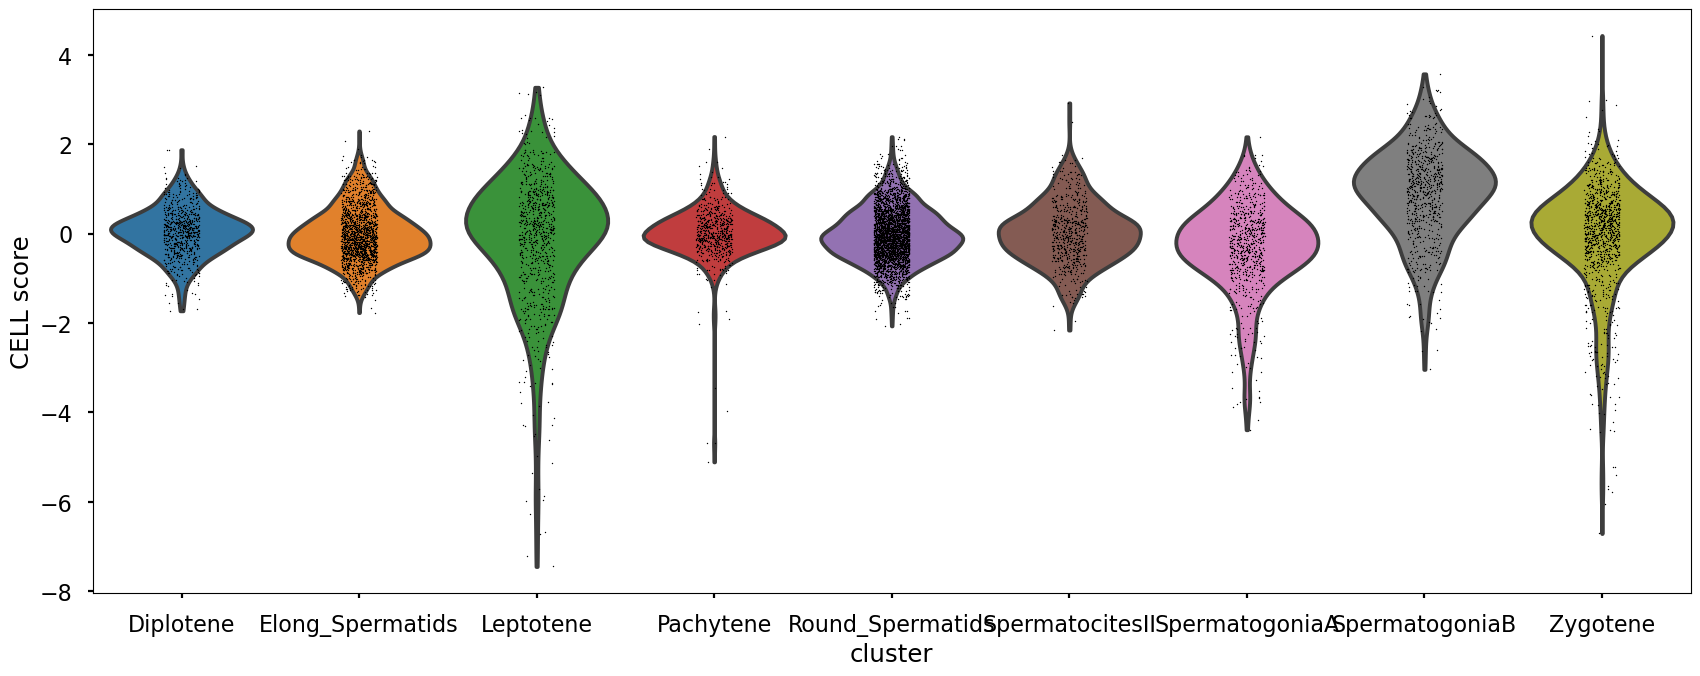

In [34]:
plt.rcParams['figure.figsize']=(16,8)
sc.pl.violin(adata, 
             groupby='spermatogenesis', keys=f'SDA_cellscore_C{comp}',
             title=f'CELLS score for SDA component C{comp}',
             xlabel='cluster', ylabel='CELL score')

(array([0, 1, 2, 3, 4, 5, 6, 7, 8]),
 [Text(0, 0, 'SpermatogoniaA'),
  Text(1, 0, 'SpermatogoniaB'),
  Text(2, 0, 'Leptotene'),
  Text(3, 0, 'Zygotene'),
  Text(4, 0, 'Pachytene'),
  Text(5, 0, 'Diplotene'),
  Text(6, 0, 'SpermatocitesII'),
  Text(7, 0, 'Round_Spermatids'),
  Text(8, 0, 'Elong_Spermatids')])

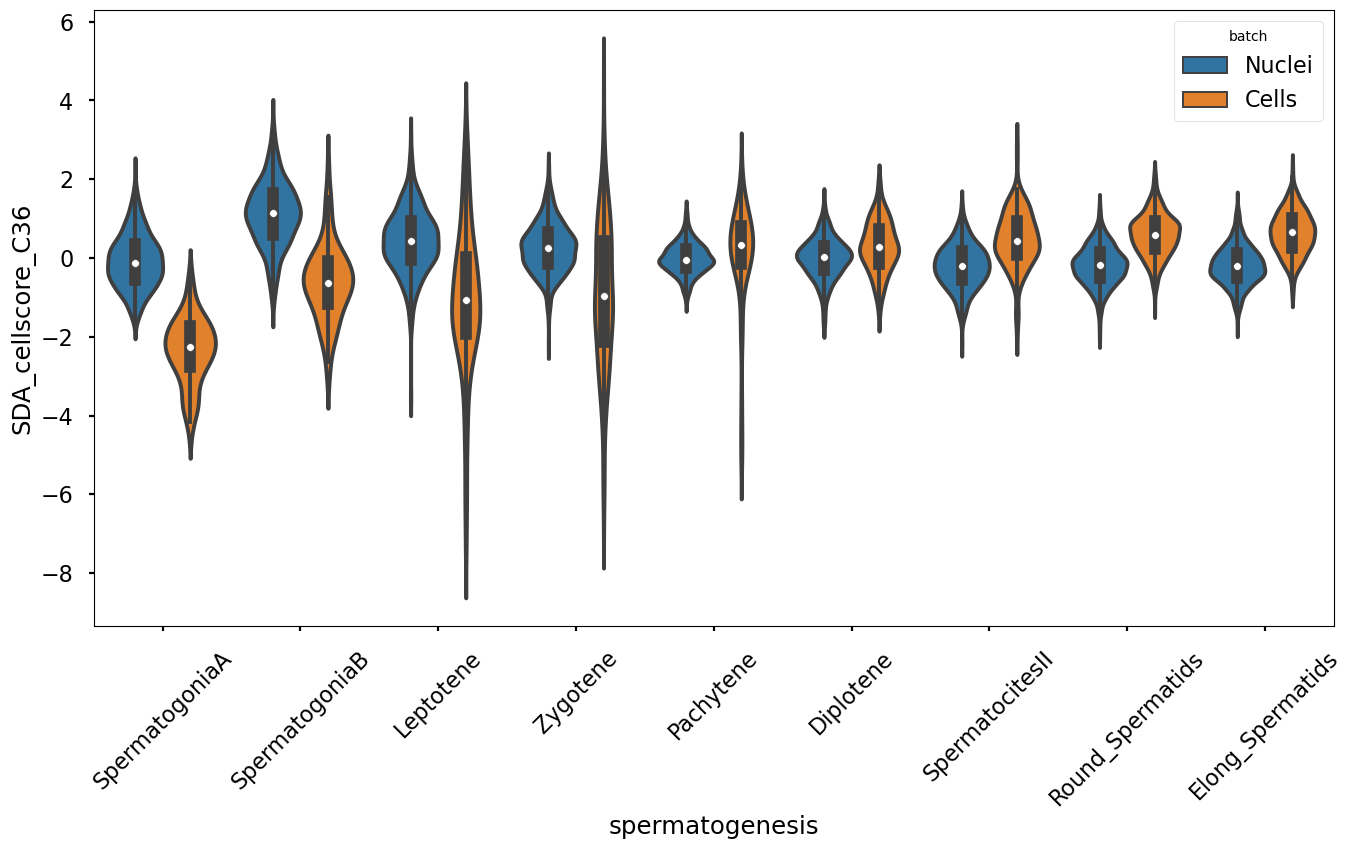

In [35]:
plt.rcParams['figure.figsize']=(16,8)
sns.violinplot(x='spermatogenesis', y=f'SDA_cellscore_C{comp}', hue='batch', data=adata.obs, 
               order=['SpermatogoniaA', 'SpermatogoniaB', 'Leptotene', 'Zygotene', 'Pachytene', 'Diplotene', 'SpermatocitesII', 'Round_Spermatids', 'Elong_Spermatids'])
plt.xticks(rotation=45)

#### Cell scores by pseudotimes and relative threshold lines

In [36]:
score_neg = -2 #min( -2, np.quantile(A[int(comp)], .1) )
score_pos = 2 #max( +2, np.quantile(A[int(comp)], .9) )

Text(0.5, 1.0, 'CELLS score in pseudotime for SDA component C36')

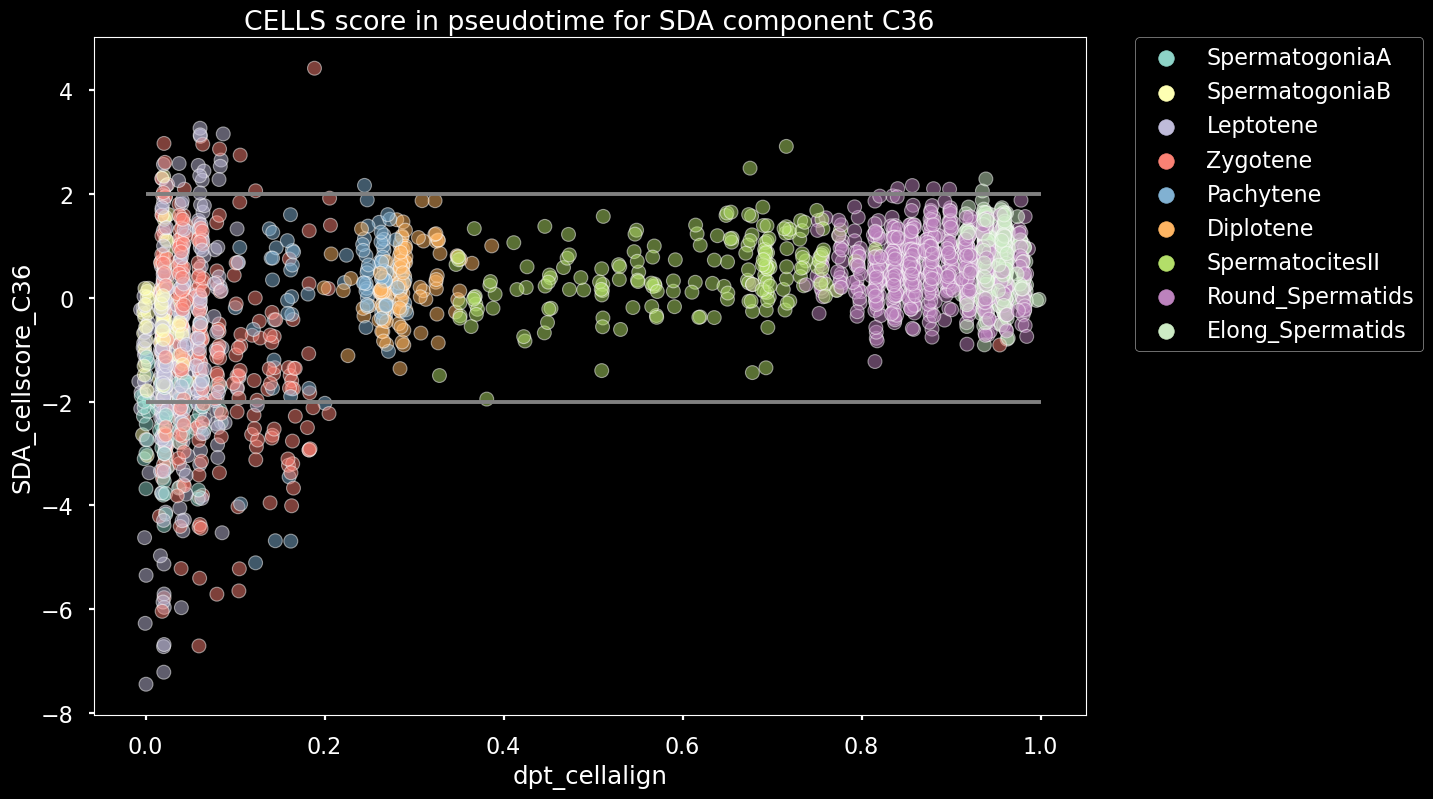

In [37]:
plt.rcParams['figure.figsize']=(16,8)
plt.style.use('dark_background')
plt.style.use('seaborn-v0_8-poster')
fig, ax = plt.subplots(1)
sns.scatterplot(y=adata[adata.obs['batch']=='Cells'].obs[f'SDA_cellscore_C{comp}'], 
           x=adata[adata.obs['batch']=='Cells'].obs['dpt_cellalign']+
                    np.random.normal(0,.0025,adata[adata.obs['batch']=='Cells'].shape[0]),
           hue=adata[adata.obs['batch']=='Cells'].obs['spermatogenesis'],
           alpha=.5, ax=ax, s=100,
           hue_order=['SpermatogoniaA', 'SpermatogoniaB', 'Leptotene', 'Zygotene', 'Pachytene', 
                      'Diplotene', 'SpermatocitesII', 'Round_Spermatids', 'Elong_Spermatids']
           )
plt.hlines(score_neg, xmin=0, xmax=np.max(adata[adata.obs['batch']=='Cells'].obs['dpt_cellalign']), colors=['gray'])
plt.hlines(score_pos, xmin=0, xmax=np.max(adata[adata.obs['batch']=='Cells'].obs['dpt_cellalign']), colors=['gray'])
plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0.)
ax.set_title(f'CELLS score in pseudotime for SDA component C{comp}')

Text(0.5, 1.0, 'CELLS score in pseudotime for SDA component C36')

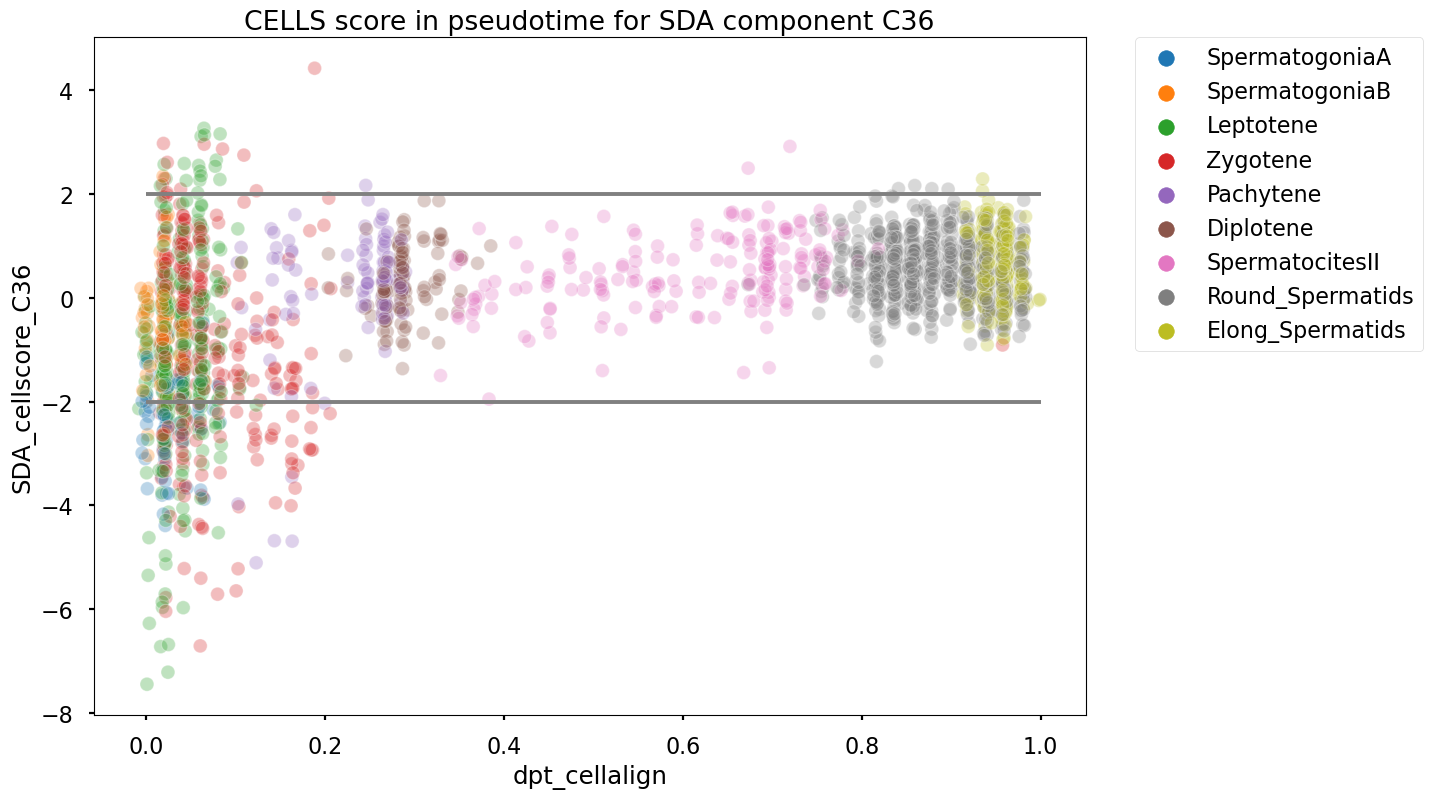

In [38]:
plt.rcParams['figure.figsize']=(16,8)
plt.style.use('default')
plt.style.use('seaborn-v0_8-poster')
fig, ax = plt.subplots(1)
sns.scatterplot(y=adata[adata.obs['batch']=='Cells'].obs[f'SDA_cellscore_C{comp}'], 
           x=adata[adata.obs['batch']=='Cells'].obs['dpt_cellalign']+
                    np.random.normal(0,.0025,adata[adata.obs['batch']=='Cells'].shape[0]),
           hue=adata[adata.obs['batch']=='Cells'].obs['spermatogenesis'],
           alpha=.3, ax=ax, s=100,
           hue_order=['SpermatogoniaA', 'SpermatogoniaB', 'Leptotene', 'Zygotene', 'Pachytene', 
                      'Diplotene', 'SpermatocitesII', 'Round_Spermatids', 'Elong_Spermatids']
           )
plt.hlines(score_neg, xmin=0, xmax=np.max(adata[adata.obs['batch']=='Cells'].obs['dpt_cellalign']), colors=['gray'])
plt.hlines(score_pos, xmin=0, xmax=np.max(adata[adata.obs['batch']=='Cells'].obs['dpt_cellalign']), colors=['gray'])
plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0.)
ax.set_title(f'CELLS score in pseudotime for SDA component C{comp}')

Text(0.5, 1.0, 'CELLS score in pseudotime for SDA component C36')

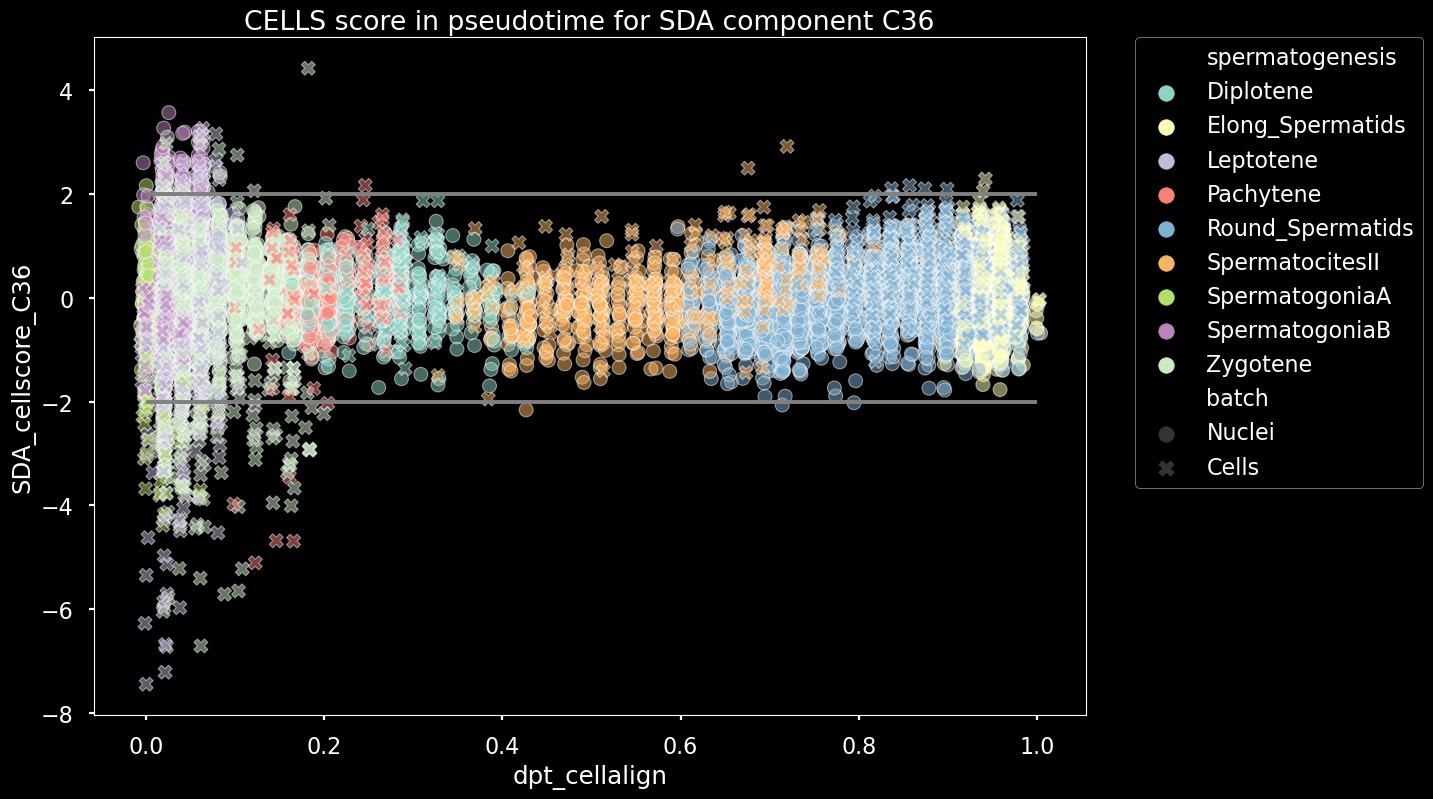

In [39]:
plt.rcParams['figure.figsize']=(16,8)
plt.style.use('dark_background')
plt.style.use('seaborn-v0_8-poster')
fig, ax = plt.subplots(1)
sns.scatterplot(y=adata.obs[f'SDA_cellscore_C{comp}'],
           x=adata.obs['dpt_cellalign']+
                    np.random.normal(0,.0025,adata.shape[0]),
           hue=adata.obs['spermatogenesis'],
           style=adata.obs['batch'],
           alpha=.5, ax=ax, s=100)
plt.hlines(score_neg, xmin=0, xmax=np.max(adata.obs['dpt_cellalign']), colors=['gray'])
plt.hlines(score_pos, xmin=0, xmax=np.max(adata.obs['dpt_cellalign']), colors=['gray'])
plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0.)
ax.set_title(f'CELLS score in pseudotime for SDA component C{comp}')

Text(0.5, 1.0, 'CELLS score in pseudotime for SDA component C36')

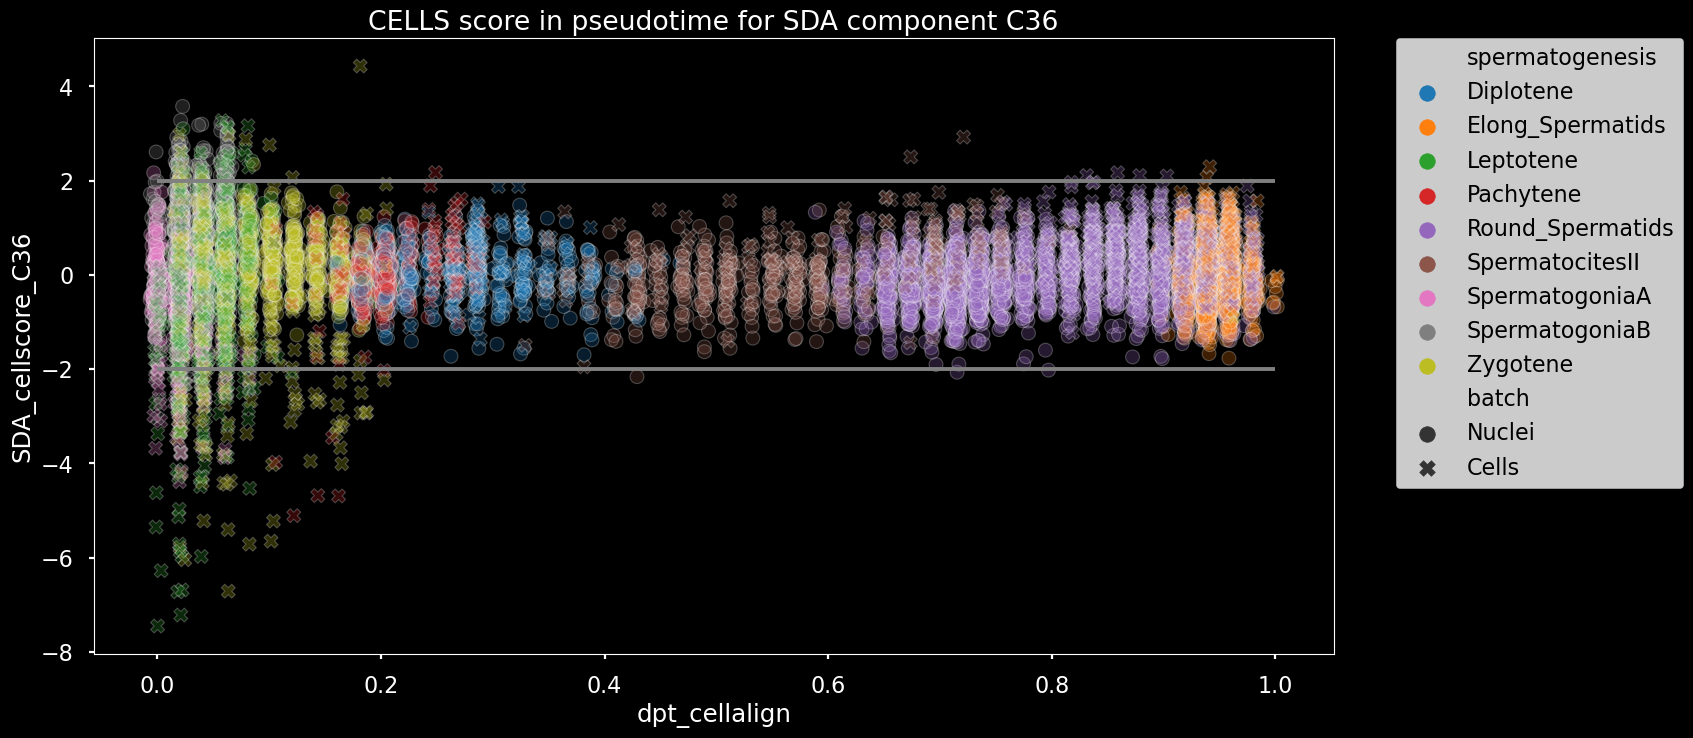

In [40]:
plt.rcParams['figure.figsize']=(16,8)
fig, ax = plt.subplots(1)
plt.style.use('default')
plt.style.use('seaborn-v0_8-poster')
sns.scatterplot(y=adata.obs[f'SDA_cellscore_C{comp}'],
           x=adata.obs['dpt_cellalign']+
                    np.random.normal(0,.0025,adata.shape[0]),
           hue=adata.obs['spermatogenesis'],
           style=adata.obs['batch'],
           alpha=.25, ax=ax, s=100)
plt.hlines(score_neg, xmin=0, xmax=np.max(adata.obs['dpt_cellalign']), colors=['gray'])
plt.hlines(score_pos, xmin=0, xmax=np.max(adata.obs['dpt_cellalign']), colors=['gray'])
plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0.)
ax.set_title(f'CELLS score in pseudotime for SDA component C{comp}')

## Gene set enrichment analysis

In [41]:
import gseapy as gp

In [42]:
!mkdir -p ./enrichment

In [43]:
genes = list( adata[:,adata.var[f'sda_pos_C{comp}']].var_names )

In [44]:
# if you are only intrested in dataframe that enrichr returned, please set outdir=None
enr = gp.enrichr(gene_list=genes, # or "./tests/data/gene_list.txt",
                 gene_sets=['KEGG_2021_Human', 'GO_Cellular_Component_2023', 'Human_Gene_Atlas'],
                 organism='human', # don't forget to set organism to the one you desired! e.g. Yeast
                 outdir=None, # don't write to disk
                )

In [45]:
enr.results[enr.results['Adjusted P-value']<.001]

,Gene_set,Term,Overlap,P-value,Adjusted P-value,Old P-value,Old Adjusted P-value,Odds Ratio,Combined Score,Genes
0,KEGG_2021_Human,Ribosome,33/158,2.856389e-18,6.969589e-16,0,0,8.569538,346.183396,RPL5;RPL30;RPL34;RPL36A;RPL9;RPL7;RPS14;RPL7A;...
1,KEGG_2021_Human,Coronavirus disease,33/232,3.491054e-13,4.259086e-11,0,0,5.362182,153.805621,RPL5;RPL30;RPL34;RPL36A;RPL9;RPL7;RPS14;RPL7A;...
2,KEGG_2021_Human,Parkinson disease,31/249,6.124553e-11,4.981303e-09,0,0,4.578182,107.661127,PRKN;PSMD11;NDUFB7;NDUFA12;NDUFB5;ITPR1;ATP5MC...
3,KEGG_2021_Human,Amyotrophic lateral sclerosis,35/364,4.368093e-09,2.664536e-07,0,0,3.428196,65.989137,PRKN;PSMD11;NDUFB7;DCTN2;NDUFA12;NDUFB5;ATP5MC...
4,KEGG_2021_Human,Huntington disease,30/306,3.635192e-08,1.616606e-06,0,0,3.483003,59.663900,PSMD11;NDUFB7;DCTN2;NDUFA12;NDUFB5;ITPR1;CLTA;...
5,KEGG_2021_Human,Prion disease,28/273,3.975262e-08,1.616606e-06,0,0,3.655805,62.297076,PSMD11;NDUFB7;NDUFA12;NDUFB5;ITPR1;ATP5MC3;COX...
6,KEGG_2021_Human,Oxidative phosphorylation,18/133,1.814653e-07,6.325362e-06,0,0,4.957981,76.958772,NDUFA8;ATP6V0B;NDUFA7;NDUFB7;NDUFA6;NDUFA12;ND...
7,KEGG_2021_Human,Pathways of neurodegeneration,37/475,3.802094e-07,1.159639e-05,0,0,2.715817,40.146689,PRKN;APP;NDUFB7;PSMD11;DCTN2;NDUFB5;NDUFA12;IT...
8,KEGG_2021_Human,Alzheimer disease,30/369,2.035124e-06,5.517446e-05,0,0,2.826365,37.039377,APP;RTN3;PSMD11;NDUFB7;NDUFA12;NDUFB5;ITPR1;AT...
9,KEGG_2021_Human,Proteasome,9/46,1.064392e-05,2.597116e-04,0,0,7.623330,87.291106,PSMD8;PSMA6;PSMD11;PSMB2;PSMA2;PSMC1;POMP;PSMB...


In [46]:
genes = list( adata[:,adata.var[f'sda_pos_C{comp}']].var_names )

In [47]:
# if you are only intrested in dataframe that enrichr returned, please set outdir=None
enr = gp.enrichr(gene_list=genes, # or "./tests/data/gene_list.txt",
                 gene_sets=['KEGG_2021_Human', 'GO_Cellular_Component_2023', 'Human_Gene_Atlas'],
                 organism='human', # don't forget to set organism to the one you desired! e.g. Yeast
                 outdir=None)

In [48]:
table_pos = enr.results[enr.results['Adjusted P-value']<.001][ ['Gene_set', 'Term', 'Overlap', 'Adjusted P-value', 'Odds Ratio', 'Combined Score', 'Genes' ] ]

In [49]:
table_pos['Component'] = f'{comp}P'

In [50]:
table_pos['Batch diff'] = batch_effect_pos

In [51]:
table_pos['N cells'] = POSITIVE

In [52]:
table_pos

,Gene_set,Term,Overlap,Adjusted P-value,Odds Ratio,Combined Score,Genes,Component,Batch diff,N cells
0,KEGG_2021_Human,Ribosome,33/158,6.969589e-16,8.569538,346.183396,RPL5;RPL30;RPL34;RPL36A;RPL9;RPL7;RPS14;RPL7A;...,36P,Yes,305
1,KEGG_2021_Human,Coronavirus disease,33/232,4.259086e-11,5.362182,153.805621,RPL5;RPL30;RPL34;RPL36A;RPL9;RPL7;RPS14;RPL7A;...,36P,Yes,305
2,KEGG_2021_Human,Parkinson disease,31/249,4.981303e-09,4.578182,107.661127,PRKN;PSMD11;NDUFB7;NDUFA12;NDUFB5;ITPR1;ATP5MC...,36P,Yes,305
3,KEGG_2021_Human,Amyotrophic lateral sclerosis,35/364,2.664536e-07,3.428196,65.989137,PRKN;PSMD11;NDUFB7;DCTN2;NDUFA12;NDUFB5;ATP5MC...,36P,Yes,305
4,KEGG_2021_Human,Huntington disease,30/306,1.616606e-06,3.483003,59.663900,PSMD11;NDUFB7;DCTN2;NDUFA12;NDUFB5;ITPR1;CLTA;...,36P,Yes,305
5,KEGG_2021_Human,Prion disease,28/273,1.616606e-06,3.655805,62.297076,PSMD11;NDUFB7;NDUFA12;NDUFB5;ITPR1;ATP5MC3;COX...,36P,Yes,305
6,KEGG_2021_Human,Oxidative phosphorylation,18/133,6.325362e-06,4.957981,76.958772,NDUFA8;ATP6V0B;NDUFA7;NDUFB7;NDUFA6;NDUFA12;ND...,36P,Yes,305
7,KEGG_2021_Human,Pathways of neurodegeneration,37/475,1.159639e-05,2.715817,40.146689,PRKN;APP;NDUFB7;PSMD11;DCTN2;NDUFB5;NDUFA12;IT...,36P,Yes,305
8,KEGG_2021_Human,Alzheimer disease,30/369,5.517446e-05,2.826365,37.039377,APP;RTN3;PSMD11;NDUFB7;NDUFA12;NDUFB5;ITPR1;AT...,36P,Yes,305
9,KEGG_2021_Human,Proteasome,9/46,2.597116e-04,7.623330,87.291106,PSMD8;PSMA6;PSMD11;PSMB2;PSMA2;PSMC1;POMP;PSMB...,36P,Yes,305


In [53]:
table_pos.to_csv(f'enrichment/enrichr_C{comp}P.csv', header=False, index_label=False, index=None, sep='\t')

In [54]:
genes = list( adata[:,adata.var[f'sda_neg_C{comp}']].var_names )

In [55]:
# if you are only intrested in dataframe that enrichr returned, please set outdir=None
enr = gp.enrichr(gene_list=genes, # or "./tests/data/gene_list.txt",
                 gene_sets=['KEGG_2021_Human', 'GO_Cellular_Component_2023', 'Human_Gene_Atlas'],
                 organism='human', # don't forget to set organism to the one you desired! e.g. Yeast
                 outdir=None, # don't write to disk
                )

In [56]:
enr.results[enr.results['Adjusted P-value']<.001]

,Gene_set,Term,Overlap,P-value,Adjusted P-value,Old P-value,Old Adjusted P-value,Odds Ratio,Combined Score,Genes
239,GO_Cellular_Component_2023,Nucleus (GO:0005634),287/4487,1.902858e-23,5.232859e-21,0,0,2.216268,115.946497,MDC1;TRRAP;MYT1L;EHMT1;PHAX;SMC3;SMC2;DCAF1;HE...
240,GO_Cellular_Component_2023,Intracellular Membrane-Bounded Organelle (GO:0...,306/5175,9.259967e-20,1.273245e-17,0,0,2.030863,89.004584,ITSN2;MDC1;TRRAP;MYT1L;EHMT1;PHAX;SMC3;SMC2;DC...
241,GO_Cellular_Component_2023,Intracellular Non-Membrane-Bounded Organelle (...,86/1195,4.316740e-09,3.957011e-07,0,0,2.115351,40.743289,MDC1;TOP2B;SETD2;NARF;HP1BP3;CHD7;FBXO25;TCHH;...
242,GO_Cellular_Component_2023,Nuclear Lumen (GO:0031981),61/780,5.084416e-08,3.495536e-06,0,0,2.278386,38.264352,TOP2B;NARF;SPO11;CHD7;FBXO25;NUCKS1;CTCF;SYNE2...
243,GO_Cellular_Component_2023,Nucleolus (GO:0005730),57/771,8.865797e-07,4.876189e-05,0,0,2.132111,29.712871,TOP2B;NARF;CHD7;FBXO25;NUCKS1;CTCF;SMC2;PHF8;G...
244,GO_Cellular_Component_2023,Nuclear Chromosome (GO:0000228),15/95,2.442051e-06,1.119273e-04,0,0,4.883407,63.106668,IK;INO80E;SPO11;TRRAP;LRPPRC;SMC2;YY1;SETX;RAD...
514,Human_Gene_Atlas,CD34+,56/645,5.122368e-09,3.739329e-07,0,0,2.552699,48.730123,TOP2B;ANKLE2;RIF1;CSE1L;AKAP8L;DDX42;NUCKS1;SM...


In [57]:
table_neg = enr.results[enr.results['Adjusted P-value']<.001][ ['Gene_set', 'Term', 'Overlap', 'Adjusted P-value', 'Odds Ratio', 'Combined Score', 'Genes' ] ]

In [58]:
table_neg['Component'] = f'{comp}N'

In [59]:
table_neg['Batch diff'] = batch_effect_neg

In [60]:
table_neg['N cells'] = NEGATIVE

In [61]:
table_neg

,Gene_set,Term,Overlap,Adjusted P-value,Odds Ratio,Combined Score,Genes,Component,Batch diff,N cells
239,GO_Cellular_Component_2023,Nucleus (GO:0005634),287/4487,5.232859e-21,2.216268,115.946497,MDC1;TRRAP;MYT1L;EHMT1;PHAX;SMC3;SMC2;DCAF1;HE...,36N,Yes,255
240,GO_Cellular_Component_2023,Intracellular Membrane-Bounded Organelle (GO:0...,306/5175,1.273245e-17,2.030863,89.004584,ITSN2;MDC1;TRRAP;MYT1L;EHMT1;PHAX;SMC3;SMC2;DC...,36N,Yes,255
241,GO_Cellular_Component_2023,Intracellular Non-Membrane-Bounded Organelle (...,86/1195,3.957011e-07,2.115351,40.743289,MDC1;TOP2B;SETD2;NARF;HP1BP3;CHD7;FBXO25;TCHH;...,36N,Yes,255
242,GO_Cellular_Component_2023,Nuclear Lumen (GO:0031981),61/780,3.495536e-06,2.278386,38.264352,TOP2B;NARF;SPO11;CHD7;FBXO25;NUCKS1;CTCF;SYNE2...,36N,Yes,255
243,GO_Cellular_Component_2023,Nucleolus (GO:0005730),57/771,4.876189e-05,2.132111,29.712871,TOP2B;NARF;CHD7;FBXO25;NUCKS1;CTCF;SMC2;PHF8;G...,36N,Yes,255
244,GO_Cellular_Component_2023,Nuclear Chromosome (GO:0000228),15/95,1.119273e-04,4.883407,63.106668,IK;INO80E;SPO11;TRRAP;LRPPRC;SMC2;YY1;SETX;RAD...,36N,Yes,255
514,Human_Gene_Atlas,CD34+,56/645,3.739329e-07,2.552699,48.730123,TOP2B;ANKLE2;RIF1;CSE1L;AKAP8L;DDX42;NUCKS1;SM...,36N,Yes,255


In [62]:
table_neg.to_csv(f'enrichment/enrichr_C{comp}N.csv', header=False, index_label=False, index=None, sep='\t')

## Plot genes average expression for positive and negative module

In [63]:
!mkdir -p ./plots

In [64]:
adata.layers

Layers with keys: SCT_counts, correct_counts, raw_counts, scaled_counts, spliced, unspliced

In [65]:
genes = list( adata[:,adata.var[f'sda_pos_C{comp}']].var_names )

In [66]:
adata.obs[f'module_pos_C{comp}'] = np.array( np.mean(adata[:,genes].layers['scaled_counts'], 1) )

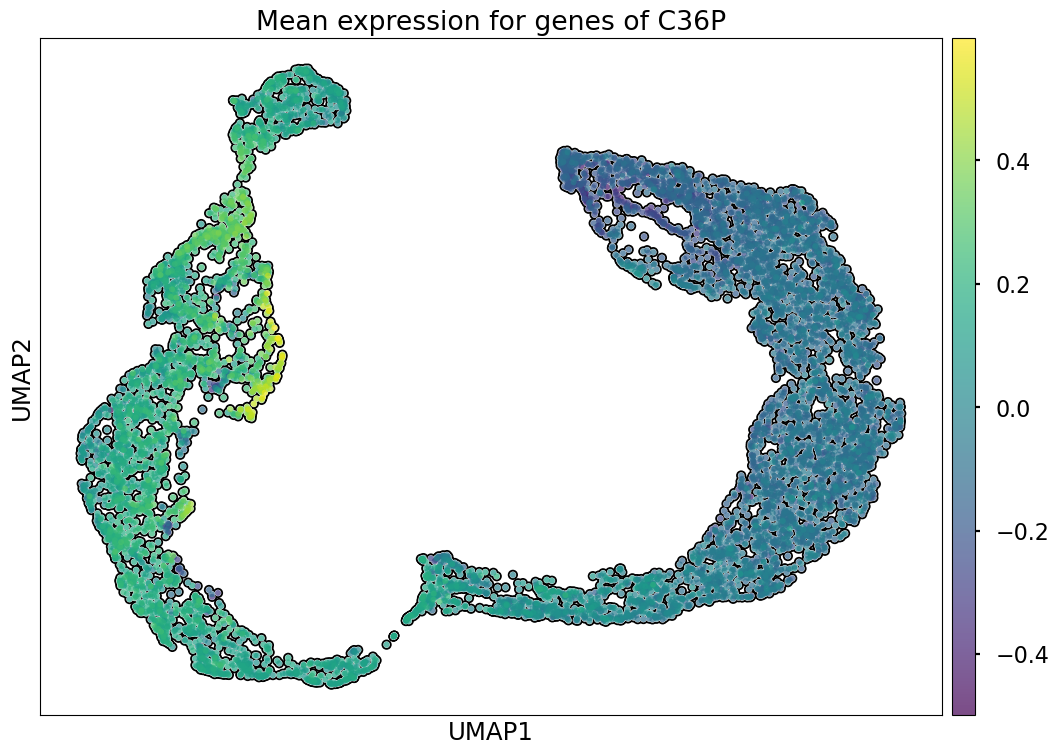

In [67]:
plt.rcParams['figure.figsize']=(7,7)
plt.style.use('default')
plt.style.use('seaborn-v0_8-poster')
sc.pl.umap(adata, color=[f'module_pos_C{comp}'], 
           add_outline=True, 
           save=f'genes_C{comp}P_white.png',
           title=f'Mean expression for genes of C{comp}P', size=75)

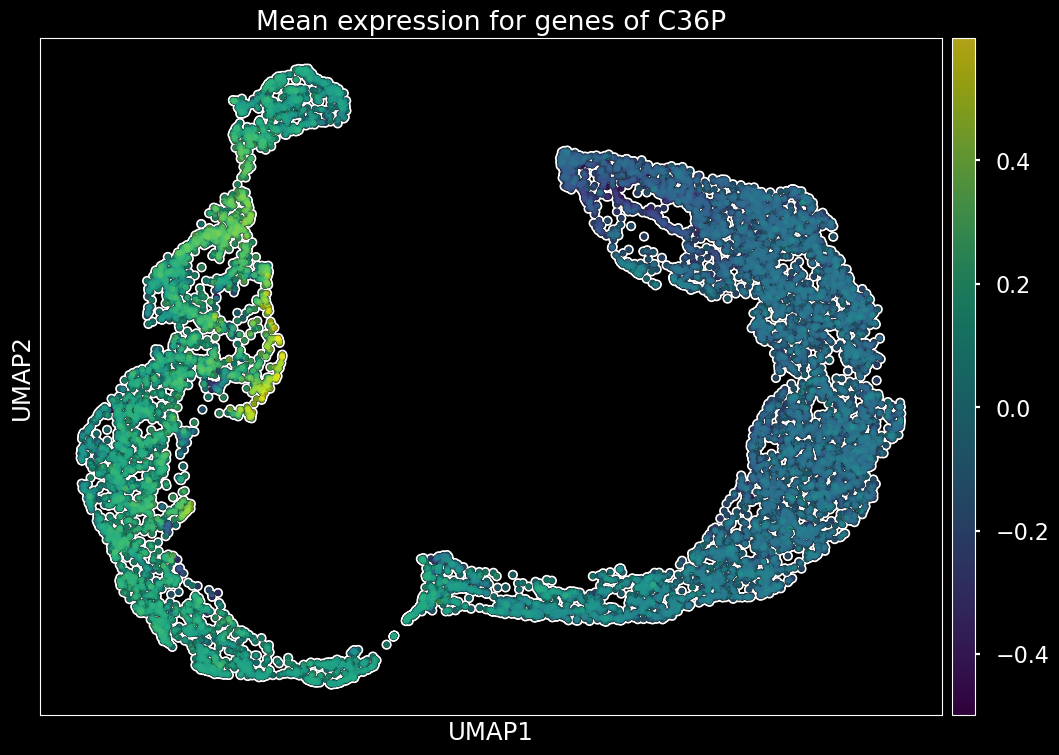

In [68]:
plt.rcParams['figure.figsize']=(7,7)
plt.style.use('dark_background')
plt.style.use('seaborn-v0_8-poster')
sc.pl.umap(adata, color=[f'module_pos_C{comp}'], 
           add_outline=True, outline_color=['white','black'],
           save=f'genes_C{comp}P_dark.png',
           title=f'Mean expression for genes of C{comp}P', size=75)

In [69]:
genes = list( adata[:,adata.var[f'sda_neg_C{comp}']].var_names )

In [70]:
adata.obs[f'module_neg_C{comp}'] = np.array( np.mean(adata[:,genes].layers['SCT_counts'], 1) )

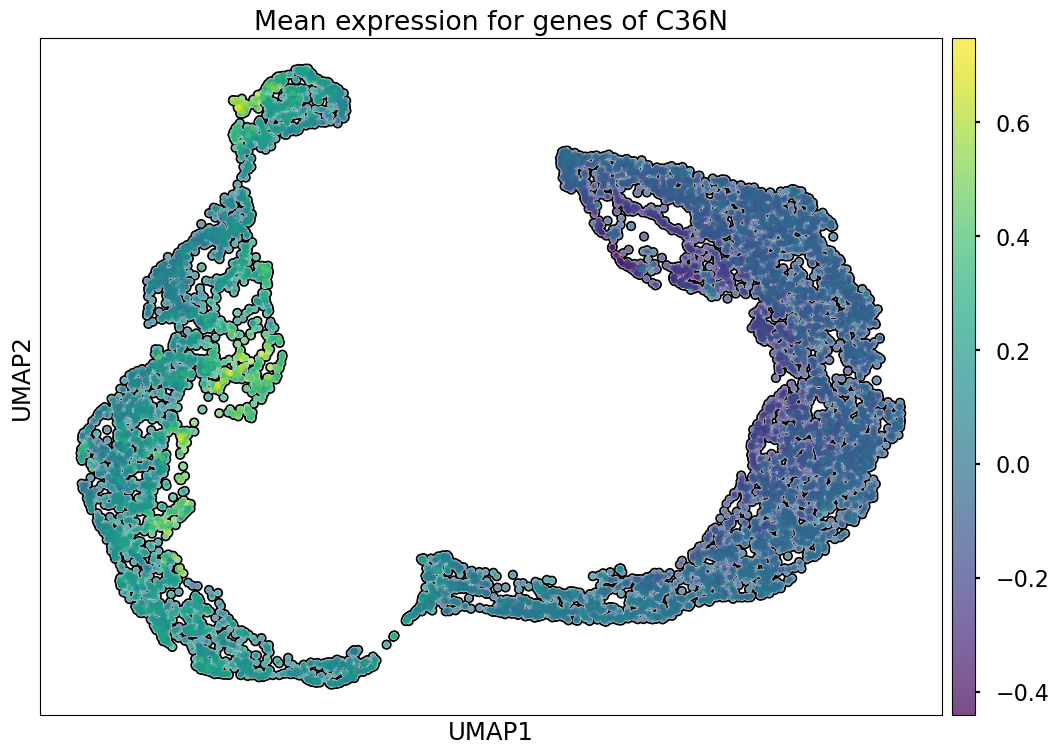

In [71]:
plt.rcParams['figure.figsize']=(7,7)
plt.style.use('default')
plt.style.use('seaborn-v0_8-poster')
sc.pl.umap(adata, color=[f'module_neg_C{comp}'], 
           add_outline=True, 
           save=f'genes_C{comp}N_white.png',
           title=f'Mean expression for genes of C{comp}N', size=75)

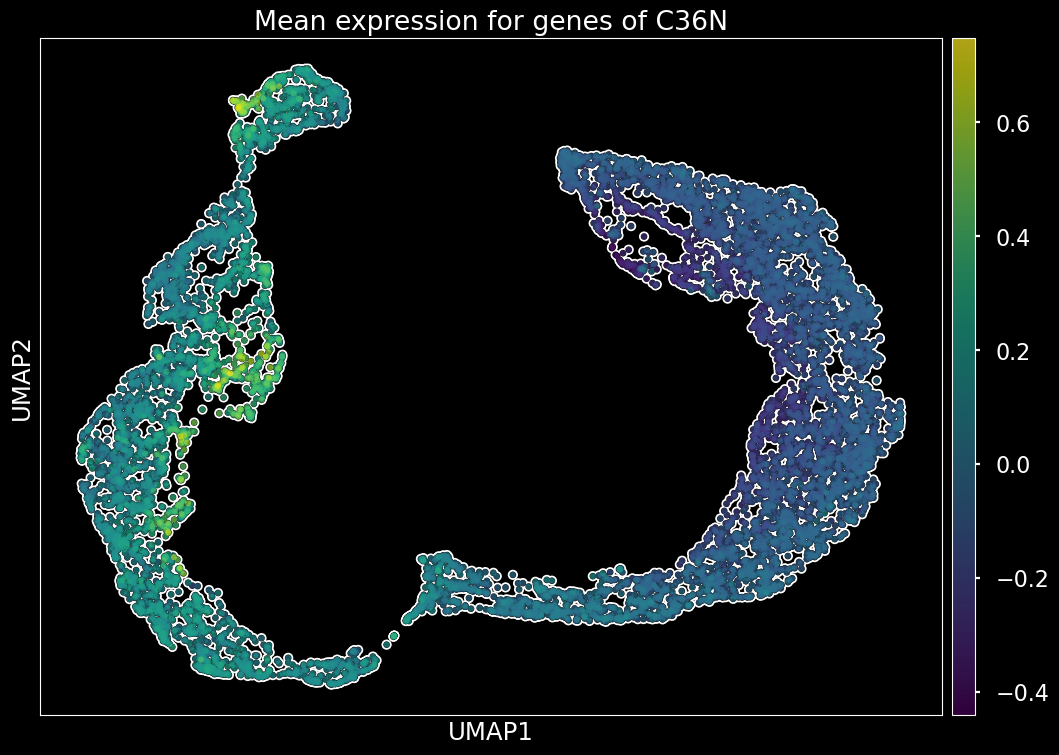

In [72]:
plt.rcParams['figure.figsize']=(7,7)
plt.style.use('dark_background')
plt.style.use('seaborn-v0_8-poster')
sc.pl.umap(adata, color=[f'module_neg_C{comp}'], 
           add_outline=True, outline_color=['white','black'],
           save=f'genes_C{comp}N_dark.png',
           title=f'Mean expression for genes of C{comp}N', size=75)